### **Importing required libraries**

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader  as dataloader
import torch.nn as nn

### **Defining the transformations**

In [ ]:
transformation_operation =  transforms.Compose([
    transforms.ToTensor()
])

### **Importing dataset**

In [ ]:
train_dataset = torchvision.datasets.MNIST(root = "./data", train = True, download = True, transform=transformation_operation)

In [ ]:
val_dataset = torchvision.datasets.MNIST(root = "./data", train = False, download = True, transform=transformation_operation)

### **Converting data to batches using DataLoader**

In [ ]:
# defining variables
batch_size = 64
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
patch_num =( img_size // patch_size )*(  img_size // patch_size )
attention_heads = 4
embed_dim = 20
transformer_blocks = 4
mlp_nodes =  64

In [ ]:
train_data = dataloader(train_dataset, shuffle = True, batch_size = batch_size)

In [ ]:
val_data = dataloader(val_dataset, shuffle = True, batch_size = batch_size)

#### ***Cheking section***

In [ ]:
# TO PRINT DIMENSIONS
images, labels = next(iter(train_data))
print("Shape of the input image tensor:")
print(images.shape)

Shape of the input image tensor:
torch.Size([64, 1, 28, 28])


In [ ]:
patch_embed = nn.Conv2d(
            num_channels,
            embed_dim,
            kernel_size = patch_size,
            stride = patch_size,
        )
print("Shape of the input image tensor after Conv2D:")

print(patch_embed(images).shape)

Shape of the input image tensor after Conv2D:
torch.Size([64, 20, 4, 4])


In [ ]:
embedded_image = patch_embed(images)
print("After Flatten:",embedded_image.flatten(2).shape)
print("After Flatten and transpose:",embedded_image.flatten(2).transpose(1,2).shape)

After Flatten: torch.Size([64, 20, 16])
After Flatten and transpose: torch.Size([64, 16, 20])


### **Part 1: Class for PatchEmbedding**

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            num_channels,
            embed_dim,
            kernel_size = patch_size,
            stride = patch_size,
        )
    def forward(self,x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x

### **Part 2: Defining the Transformer Encoder**

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(
            embed_dim,
        )
        self.layer_norm2 = nn.LayerNorm(
            embed_dim,
        )
        self.multi_head_attenrion = nn.MultiheadAttention(embed_dim, attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes, embed_dim)
        )

    def forward(self, x):
        residual_1 = x
        x = self.layer_norm1(x)
        x = self.multi_head_attenrion(
            x,
            x,
            x
        ) # RETURNS: [output, attention_weights]
        x = x[0] + residual_1
        residual_2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x) + residual_2
        return  x


### **Part 3: NLP Head**

In [ ]:
class MLP_Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x = x[:, 0]
        x = self.layer_norm_1(x)
        x = self.mlp_head(x)
        return x

### **Part 4: Vision Transformer**

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        # CLS TOKEN: (1, 1, embed_dim)
        # 1 = one initial CLS token
        # 1 = one token position
        # embed_dim = number of features in the CLS token
        self.positional_encoding  = nn.Parameter(torch.randn(1, patch_num+1, embed_dim))
        # POSITIONAL ENCODING: (1, patch_num + 1, embed_dim)
        # 1 = one initial set of positional embeddings
        # patch_num + 1 = positions for all patches + CLS token
        # embed_dim = features for each position

        self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)] )
        self.mlp_head = MLP_Head()

    def forward(self, x):
        x = self.patch_embedding(x)
        b = x.shape[0]
        cls_tokens = self.cls_token.expand( b, -1,-1)
        x = torch.cat((cls_tokens, x), 1)
        x = x+self.positional_encoding
        x  = self.transformer_blocks(x)
        x = x[:, 0]
        x = self.mlp_head(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.6349, Accuracy = 6.25%
  Batch 101: Loss = 2.3014, Accuracy = 7.81%
  Batch 201: Loss = 2.2941, Accuracy = 15.62%
  Batch 301: Loss = 2.3168, Accuracy = 9.38%
  Batch 401: Loss = 2.3139, Accuracy = 4.69%
  Batch 501: Loss = 2.3131, Accuracy = 7.81%
  Batch 601: Loss = 2.2968, Accuracy = 14.06%
  Batch 701: Loss = 2.2951, Accuracy = 7.81%
  Batch 801: Loss = 2.3079, Accuracy = 6.25%
  Batch 901: Loss = 2.3026, Accuracy = 9.38%
==> Epoch 1 Summary: Total Loss = 2163.9166, Accuracy = 10.56%

Epoch 2
  Batch   1: Loss = 2.3100, Accuracy = 9.38%
  Batch 101: Loss = 2.2912, Accuracy = 10.94%
  Batch 201: Loss = 2.3042, Accuracy = 9.38%
  Batch 301: Loss = 2.3000, Accuracy = 9.38%
  Batch 401: Loss = 2.2939, Accuracy = 10.94%
  Batch 501: Loss = 2.2994, Accuracy = 9.38%
  Batch 601: Loss = 2.3041, Accuracy = 12.50%
  Batch 701: Loss = 2.3136, Accuracy = 1.56%
  Batch 801: Loss = 2.3053, Accuracy = 6.25%
  Batch 901: Loss = 2.3085, Accuracy = 7.81%
==> Epoch 2 Su

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 10.28%


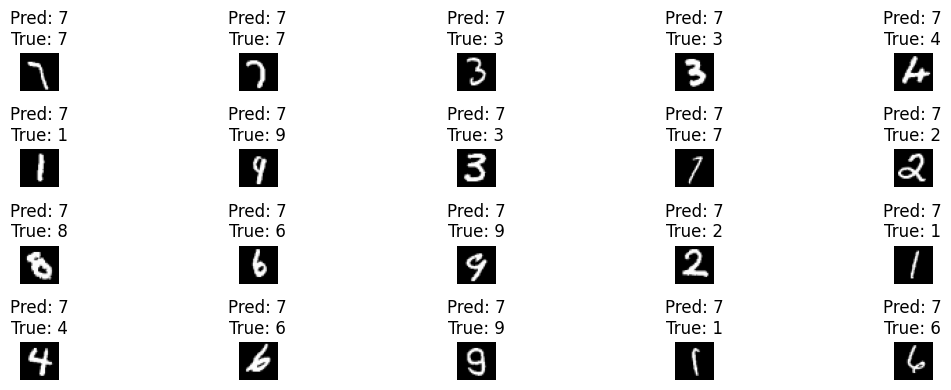

In [ ]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Get one batch from the validation data
images, labels = next(iter(val_data))

# Print the shape of the images tensor
print("Shape of images in a batch:", images.shape)
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
embedded_data = patch_embed(images)
embedded_data = embedded_data.flatten(2)
embedded_data = embedded_data.transpose(1,2)
print("Shape of embedded data:", embedded_data.shape)
print(torch.randn(1,1,embed_dim).shape)

# You can also print the shape of the labels tensor if you'd like
# print("Shape of labels in a batch:", labels.shape)

Shape of images in a batch: torch.Size([64, 1, 28, 28])
Shape of embedded data: torch.Size([64, 16, 20])
torch.Size([1, 1, 20])
